# DSP Methodology

In [1]:
%matplotlib widget

import sys; sys.path.insert(0, '../../../research')
from dsplot.figures import figure_1, figure_2_4_1, figure_2_4_2, figure_2_4_3

## 1. Motivations
- To visualize an audio signal effectively, we need a precise method for representing it's behavior
- Specifically, we want to know **what** frequencies are present and **when** they occur in the signal 
- This is the primary motivation for finding a highly accurate **time-frequency** analysis method 
  - The textbook approach is the **Fourier Analysis**, but in this context it has limitation
  - The more recently popularized **Wavelet Analysis** is much better suited for this kind of task
- Both are built on the same foundation - **signal decomposition** 
- Beginning with simple examples, we will build up to a comprehensive and intuitive understanding of how these methods actually work, and explore the different areas where they excel and fall short

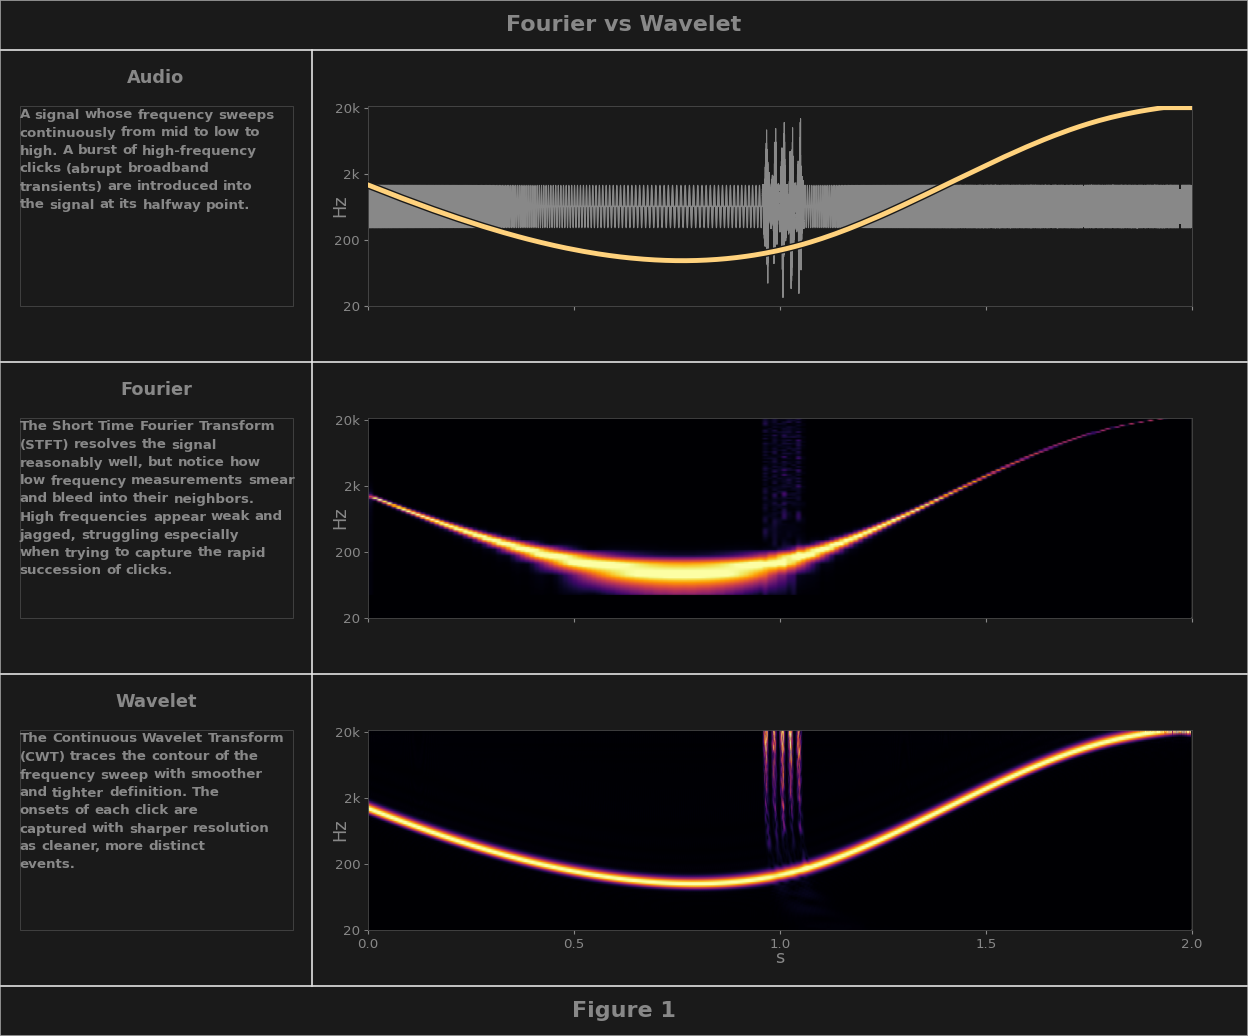

In [2]:
figure_1()

---

## 2. Foundations

### 2.1 Signal Decomposition - The Goal

- The end goal is to **decompose** any given signal into its fundamental **components**
- In simpler terms, we want to break a signal down into its **basic building blocks** and see how much of each "block" exists in the signal originally 
- This is like trying to unmix a can of paint to figure out how much of each color ingredient contributed to the overall color of the paint - where would you even begin?
- This type of problem motivates us to do two things:
    1. **Define what a signal's fundamental components are** 
    2. **Measure the presence of each component in the signal** 
- This is where the **Inner Product** comes into play - it's a general-purpose tool for measuring signal components, and we will explore these two motivations in different contexts


### 2.2 Inner Product - The Tool

- The **Inner Product** gives us a generic way to compare and compute a "**similarity score**" between
    - A function **f** - the signal 
    - A reference function **g** - something that embodies the signal properties we want to measure 

<div align="center">

$$
\langle \, 
\mathbf{f} \, , \, 
\mathbf{g} \,
\rangle 
$$

<em>Inner Product Notation</em>

</div>

- The result is a measurement of how **correlated** these function are, indicating their **similarity**
- But to understand how this actually works, it's helpful to see how the Inner Product operates in its simplest form: the **Dot Product**



### 2.3 Dot Product - The Basic Case

- The Inner Product generalizes what the **Dot Product** does to **vectors** in $\mathbb{R}^n$ 
- This just means we'll be applying these concepts to just plain, regular, real numbers - no imaginary or abstract numbers in weird math domains (yet)
- As long as you can do basic **multiplication** and **addition**, it's really not too bad

<div align="center">

$$
\vec{a} \cdot\vec{b} = \sum_{i=0}^{n} a_i b_i
$$

<em>Dot Product Notation</em>
</div>

- In plain English this is called a **sum of products** - **multiply** each term in vector **a** with each term in vector **b** and then **add** them all together
    <!-- 1. Take the first term from **a** 
    2. Take the first term from **b**
    3. **Multiply** them together
    4. Repeat 1-3 for each pair of terms
    5. **Add** up all the multiplied terms together -->

<div align="center">

$$
\vec{a} = 
    ( \,
    a_0 \, , \,
    a_1 \, , \,
    a_2 \, , \, 
    \ldots \, , \,
    a_n \, )
$$

</div>

<div align="center">

$$
\vec{b} = 
    ( \,
    b_0 \, , \,
    b_1 \, , \,
    b_2 \, , \, 
    \ldots \, , \,
    b_n \, )
$$

</div>

<div align="center">

$$
\vec{a} \cdot\vec{b} = 
    a_0 \cdot b_0 \, + \,
    a_1 \cdot b_1 \, + \,
    a_2 \cdot b_2 \, + \, 
    \ldots \, + \,
    a_n \cdot b_n \, 
$$

<em> Dot Product Operation </em>
</div>

- But what does this result even really mean? And what does this operation even really do? 
- Spoiler, the result indicates how **parallel** vectors **a** and **b** are - this is the key insight to understanding that the Dot Product operation measures **"similarity"** by  calculating how **aligned** **a** and **b** are in terms of their "parallel-ness"
- This clicks more visually during **Vector Projection**, our first attempt at any form of **decomposition**


### 2.4 Vector Projection - The Geometric Interpretation

#### 2.4.1 Projecting onto a Reference Direction

- A **vector** can be thought of as an **arrow** described by two of its properties
  - **magnitude** - how long it is 
  - **direction** - where it points

- To **decompose** a vector, or break it down into its most basic components, we **project it along** the directions of **all the dimensions** it exists in - **Figure 2.4.1.a**
  - Since **a** is defined by two dimensions, think of it like the vector casting its **"shadows"** onto the x and y axes 
  - Notice how as **a** grows or shrinks in a particular direction, the "shadow" **aligned** with each dimension compensates itself accordingly
  - This illustrates how projecting **a** onto these axes reveals the components of **a** that are **parallel** to x and y 

- We are able to designate these "shadow" lengths as the vector's **basic components** since they
  1. **Can be combined in any order** to reconstruct the original - **Figure 2.4.1.b** 
      - Stacking the components tip-to-tail rebuilds vector **a** 
      - Notice when recombining these components - either starting with x first and then y, or y first and then x, regardlessly, you still end up with the **original**
  2. **Measure independent information** about the original - **Figure 2.4.1.c**
      - Being independent of each other means knowing the value of one component **tells you nothing** about the other 
      - Notice how as the vector sweeps through each direction, the other direction's component is fully unaware and unaffected 
      - Since they point at **right angles** to each other, each dimension is **unrelated** -.
       **x cannot measure any information that y measures** and vice versa - we call this being **orthogonal**

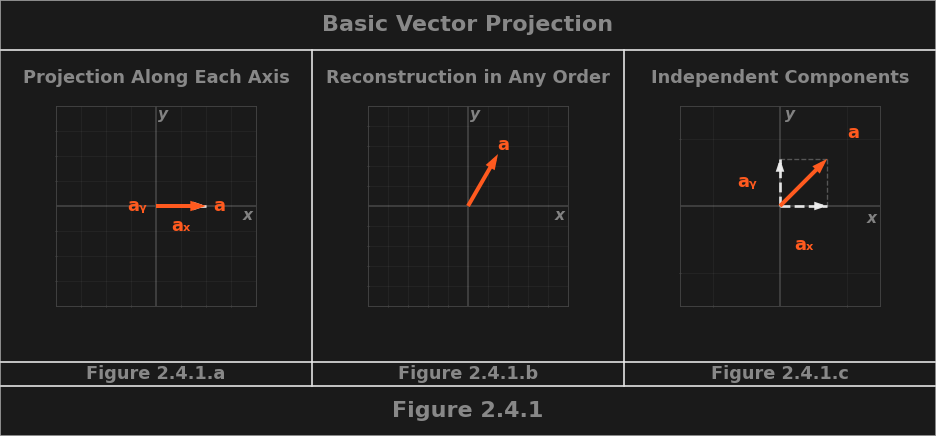

In [3]:
figure_2_4_1() # have 241c pause one frame in between sweeping each component

#### 2.4.2 Projecting onto Another Vector in 2D

- So far we've established how projection reveals a vector's **parallel component**  
  - Previously, we projected onto the directions of the familiar **x and y axes** to reveal the components **parallel to them** 
  - Similarly, we can project onto the direction of **any other vector** to reveal the component **parallel to it**
  - This involves the two vectors in an interesting relationship 

- The relative **angle** between **a** and **b** has direct control of the projected parallel component - **Figure 2.4.2.a**
  - Here you can see its **size and direction** track the **alignment** of the two vectors by 
    - Growing **large in one direction** when they point **similarly parallel** 
    - Reducing to **zero** when they point perpendicularly (perfectly **not parallel**)
    - Growing **large in the other direction** when they point **oppositely parallel**

- This relationship should sound familiar
  - Earlier, we claimed performing the Dot Product on two vectors produces a "similarity score" for the same thing
  - Yet the operation itself is deceptively simple - all you do is **multiply** corresponding terms and **add** them together
  - How does a simple **multiply-and-add** operation, performing *no visible trig*, capture a relationship clearly so dependent on the vectors' relative angle?

- It turns out the Dot Product and Vector Projection are two views of a shared geometric relationship - **Figure 2.4.2.b**
  - We can derive the Dot Product from the **triangle** formed by the vectors like in [this video](https://youtu.be/PnJoKGynu_U?si=qr-2XD9gF5MeU9n5) - it abides the age-old [Law of Cosines](https://www.reddit.com/media?url=https%3A%2F%2Fcf.preview.redd.it%2Flaw-of-cosines-v0-arli6kvsxkga1.jpg%3Fwidth%3D1080%26crop%3Dsmart%26auto%3Dwebp%26s%3D6fd1802a88aa4c78470f2878b22f684e43d8765b) which is like the Pythagorean Theorem but for any triangle
  - Basically, as the angle between the vectors changes, their **x** and **y** components are simultaneously **changing with it**
  - This means the Dot Product already has this precious angle **baked into** the components **before** operating on them directly

<div align="center">

$$
\vec{a} \cdot \vec{b}
=
|\vec{a}| |\vec{b}| \cos(\theta)
=
a_x b_x + a_y b_y
$$

<em>2D Dot Product - Cosine and Component Form</em>

</div>

- This lets us use the Dot Product and Vector Projection as different framings of the same relationship - parallelism
  - Both measure the **alignment** of two vectors, which we said reflects their **similarity**
    - Projection reveals this geometrically through **trig** using each vector as a whole
    - The Dot Product computes it using a simple **sum of products** on their individual components
  - Naturally, this relationship exists beyond two dimensions

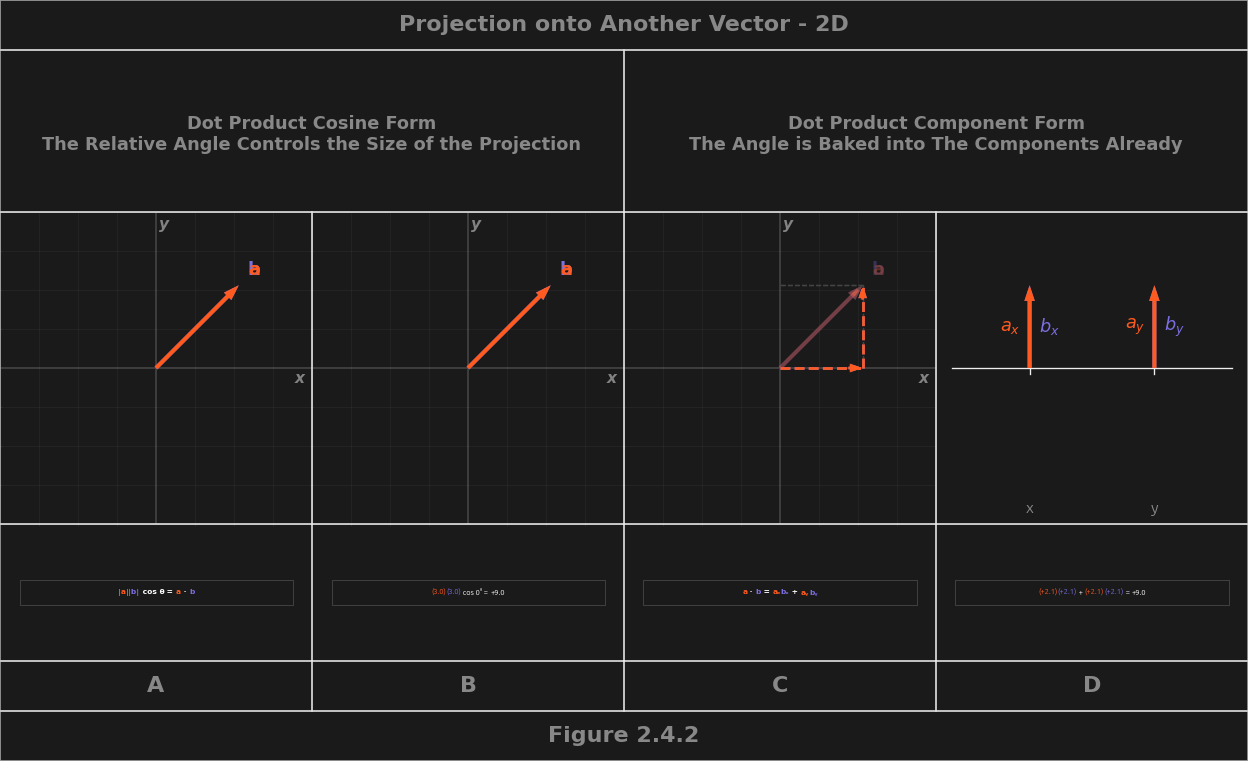

In [4]:
figure_2_4_2()

#### 2.4.3 Projection in 3D and Beyond

- The Vector Projection and Dot Product equivalence also extends to vectors described by **three** dimensions - **Figure 2.4.3.a**
  - To add a third axis, we orient the z axis at **right angles** to the others x and y 
  - It's important they are all **perpindicular** - as we said in §2.4.1 this relationship relies on them all being **independent** of one other
  - The parallel projection and triangle relationship still occur here, but the angle becomes tough to isolate even with trig now that it cuts across multiple axis planes
  - It's a lot simpler for us to just use the Dot Product on the individual components to score their similarity

- To no surprise, this relationship applies to **any number** of dimensions
  - Past three dimensions, we can no longer visualize the projection - it's not visually possible to orient any more axes at right angles to the others
    - At this point, we need to reconsider what a vector and its components really are
    - For three dimensions, each vector is a set of three components whose values represent the independent contributions of each dimension
    - For any number of dimensions, we will treat every vector like a **collection of "independent values"** instead of "dimensions"
  - The audio signals we'll be working with are all just collections of **independent audio samples** measured in time 
    - Not measured along x, y, or z - just a set of independently measured **values** sampled in time - usually way more than just three
    - What we really care about here is the concept of computing the **similarity** between two sets of these values 
    - To finally lock this in intuitively, we will examine how the Dot Product works operationally, dropping the "dimension" language

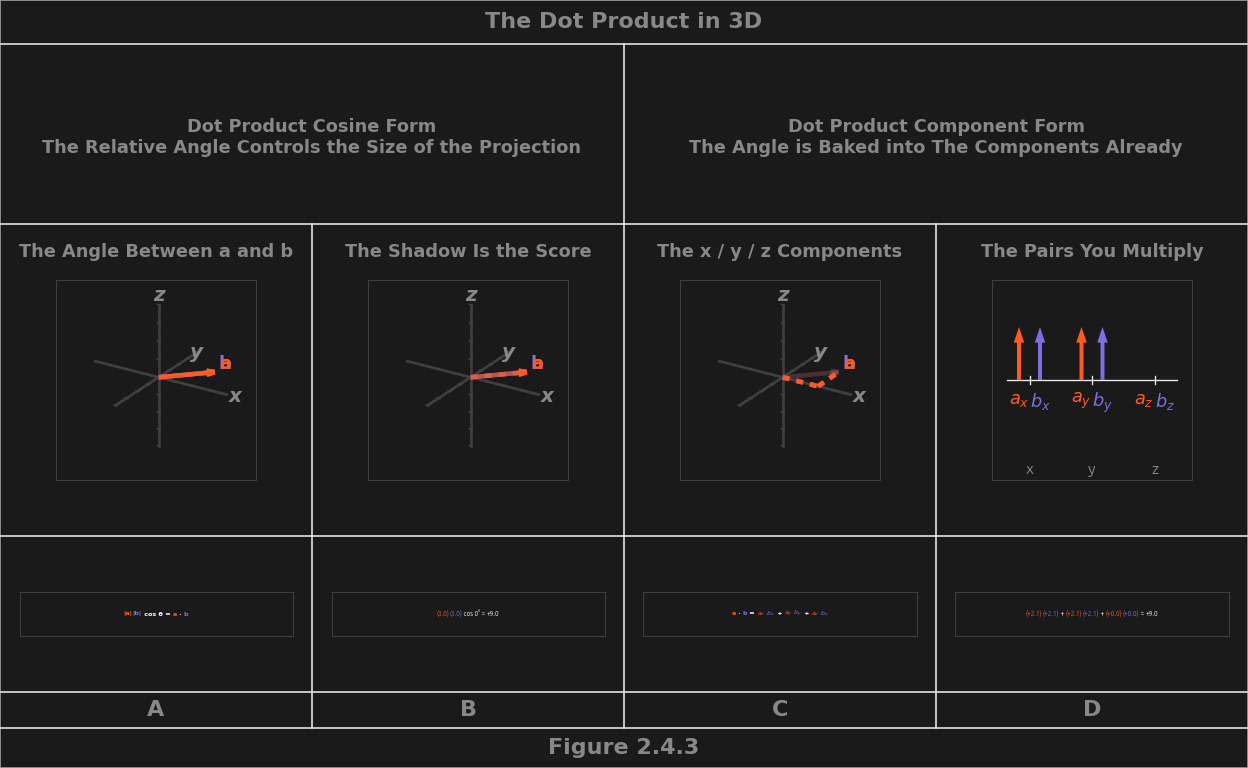

In [5]:
figure_2_4_3()

## 2.5 Sign Accumulation - The Agreement Mechanism

- The Dot Product accumulates the **sign agreement** for two sets of values into a **single running sum**
  - We perform the multiply-and-add operation for every pair of values in each set - this is what is known as **correlation**
  - Each **product** reveals whether the pair of values move in the same direction
    - When they **agree** in sign, their product **increases** the sum - **positive correlation**
    - When they **disagree** in sign, their product **decreases** the sum - **negative correlation**
    - When one is **zero**, their product contributes **nothing** to the sum - **no correlation**
  - The **sum** of all products captures the total sign agreement across every pair into a net result
  - Technically, correlation involves normalizing the values being compared - but the underlying operation is functionally the same

  <!-- example all except one sign are the same, some are same, some are oppsoite, all except one are opposite, some are zeros, all are zeros -->

- This **agreement mechanism** is the true essence of what the Dot Product is really doing
  - We're not *just* measuring similarity - that's the simple way of looking at it
  - Through Vector Projection, we introduced the concept of decomposing something whole into its parts
    - This revealed what two vectors have in **common** using parallel projections
    - But this geometric view doesn't help us past three "dimensions"
  - The Dot Product is much more convenient for us now than ever 
    - Measuring sign agreement captures this same exact relationship 
    - This allows us to compare how similar two sets of values are, for any number of values
    - In a deeper sense, it allows us to measure the **presence of "something" within another**

- This ties us back to our original motivations in §2.1 
  - We want to measure the presence of "something" within an audio signal using the Dot Product
  - But this begs the question, how do we pick the "something" that we are comparing the audio against?


## 2.6 Basis Functions - Full Signal Decomposition

- Choosing a set of functions to completely represent all the properties we're interested in measuring is how we acheive full signal decomposition
   - In its raw form, a signal's properties are all mixed together — we can't see or work with any of them individually
   - Signal decomposition separates what's tangled
     - Re-representing all the information in a different, more convenient form
     - This is the entire point of everything we've been building — the Dot Product, correlation, sign accumulation — all of it serves this goal
   - We're no longer working with plain vectors — we're working with **sets of independent values**
     - The audio signal is one set
     - A reference function encoding a property we want to measure is the other

- Example: measuring frequencies with sine waves
   - To analyze a signal for a **particular frequency**, we make the reference function a pure sine wave oscillating at that frequency
     - The Dot Product tells us whether that frequency is present in the original signal — **Figure 2.6**
     - This is how frequency, a signal property embodied in our reference function, gets measured by the Dot Product
   - And what if a signal contains **multiple frequencies** and we wanted to measure more than just one?
     - Perform the Dot Product multiple times with sine functions at different frequencies
     - Each Dot Product result measures the presence of each frequency

- From measurements to a basis
   - What we're really trying to do is **completely represent** all the information in the original signal
     - If we're not careful about which frequencies we choose, we could measure the same information more than once
   - For a complete and **non-redundant** representation, each reference function must measure something the others don't
     - A set that achieves this is called a **basis**
     - Each function is **orthogonal** to the others
   - This allows us to view and work with the signal in a more convenient format
     - Using sine waves as a set of basis functions will show us which frequencies are present in the original
     - While preserving the ability to **reconstruct** it back to the original
   - For frequency analysis, sinusoidal basis functions are the natural choice — but which frequencies do we pick? → Section 3

## 2.6 Basis Functions - Full Signal Decomposition

- We're no longer working with plain vectors - we're working with **sets of independent values**
  - One of these sets will be the audio signal we are analyzing 
  - The other set will be a reference function containing the properties we are interested in measuring 
  - The result of their Dot Product is a singular correlation result - a measurement of how much of that property is present in the audio

- To analyze a signal for a **particular frequency**, we could make the reference function a pure sine wave oscillating at that frequency
  - Performing the Dot Product tells us whether or not its frequency is present in the original signal - **Figure 2.6**
  - This is how a signal property emobodied in a reference function gets measured by the Dot Product 

- But what if a signal contains **multiple frequencies**?
  - To measure them each, we perform the Dot Product multiple times with several different sine functions 
  - Each one measures the presence of a different frequency 

- What we're really trying to do is **completely represent** all the information in the original signal
  - Each Dot Product with a different sine wave measures the presence of a different frequency
  - But if we're not careful about which frequencies we choose, we could measure the same information more than once 
  - For a complete and **non-redundant** representation, each reference function must measure something the others don't
  - A set of reference functions that achieves this is called a **basis** - each function is **orthogonal** to the others, similar as before

- This is how we accomplish full **signal decomposition** - re-representing all the information from the original in a different form
  - Doing this allows us to work with the signal in a more convenient format, while preserving the ability to **reconstruct** it back to the original 
  - For frequency analysis, creating a set of sinusoids for a basis is the natural choice

<!-- - What we are trying to do here is completely represent all the information in the original audio
- This allows us to measure a collection of Dot Product results - comparing the same audio signal with multiple sine-wave reference function
  - But what is this really doing?
    - We're really creating a set of functions that represent all the properties aligned with each frequency - ehh i don't like how this sound
    - How do we decide which frequencies to include in our set?
      - We have the choice to use any and all frequencies we are interested in measuring, but if we're not careful, we could actually redundantly represent information in the original
      - Each function, like the individual components from earlier, need to measure information in the original that the others don't — if they overlap, we capture the same information redundantly

  - A set of reference functions that satisfies this is called a **basis**
    - Each basis function is orthogonal to the others — together they produce a **complete**, **non-redundant** representation
    - This is signal decomposition — and for frequency analysis, sinusoidal basis functions are the natural choice


### 2.6 Basis Functions - Achieving Signal Decomposition
- so as we are expanding our intuition, we need to think about why we are doing any of this in the first palce
- we are trying tie this all back to being able to look at a signal, and figure out what frequencies are being played
- so we need a way to meausre the signal and measure the presence o

- Accomplishing this really depends on the signal being analyzed and the properties we're interested in measuring
- The function we compare against is called a **basis function** - a known reference **pattern**
- The choice of basis function determines what features we can detect
- The scalar result of this comparison is called a **coefficient** - it tells you "how much" of that basis function is present

<!-- FIGURE relocated here from §2.4 per the consolidation pass - once §2.6
     is being authored, place the tip-to-tail recombination panel where it
     reinforces "components form a basis": the same components recombined
     in different orders both reconstruct a, which is exactly the property
     a basis function family relies on.
     ![Same components recombined tip-to-tail in opposite orders both reconstruct a](../../../assets/images/dsp/figures/vector_xy_reconstruction/baseline.png)-->

<!-- This is all about re-representing **all the information** from the original signal into a **different format**, while also being able to perform the **reverse process** to **reconstruct** the original   -->


<!-- ## 3. Fourier Transform: Sinusoidal Basis Functions --> 


<!-- ---

- At this point, we are no longer treating these "things" as "vectors" but instead sets of independent values
    - When we were working with vectors, we treated them as sets of independent dimensional components
    - Now we are treating them as functions - sets of independent values
  - One of these sets will be the audio signal function we are analyzing 
  - The other set will be a reference function containing the properties we are interested in discovering 

- To measure the presence of something inside something else, we first need to **define what that something is**
  - How do we do that
  - Tying us back to our decomposition criteria, we need to ensure 
  - Each value represents unique, non-overlapping information, so no information from the whole is captured redundantly
  To do that, we compare against a known reference pattern called a **basis function**



  * The result of this comparison is a **coefficient** - a scalar telling us *how much* of that pattern is present

* But we are not interested in measuring isolated pieces alone

  * We want to re-represent **all of the information** from the original signal in a different form
  * And critically, we want to be able to **reconstruct the original**

* This means our basis functions must satisfy two important requirements

  * They should measure **independent things**
  * Together, they should completely represent the original information

* This brings us back to our original motivation

  * If our goal is to understand what **frequencies** are present in a signal, we should probably choose basis functions that themselves embody **frequency** -->


## 3. Fourier Transform: Sinusoidal Basis Functions

### 3.1
At this point we have an operation that can measure the signal properties we are interested in measuring 
and a goal of completely representing the original signal using these properties using a set of basis functions

Last sectoin we said we need to specifically pick the referene functions so they accurately represetn tht eoriginal's information

So how exactly do we do this

The Fourier Transform uses sinusoids to represent all the information in a signal - we say sinusoid instead of sine wave because its more than that but for now we'll stick with sine waves

So when we go to pick the frequencies - which ones? We could try all of them? What is all of them, well thats determined by NyQuist 

but if we did all the way up to the nyquist, we would get a lot of redundant information? why? discrete values, if it were continuous, it'd be different story

but we're in discrete land, so since these truly as just values, what kind of values are they? they're measuremetns ampledin time, so they have a width a part - dictated by how often we take a sample - sampling frequency, reducing how often we sample is the same thing as spacing these samples far apart in time

this affects the upper limit of frequencies we can measure nyquist link explaining this

this is the nyquist law we abide by in discrete - we have to consider how spaced apart these measurements are taken becauase we can't capture information from the signal more finely than that - so properties that are represented by information that would be captured between those points can't be measured - this actually gives us aliasing - measuring for a more higher frequency property will incorrectly measure information measured by other basis functions

also, heres why theryre binned, the width o feah bbin is dictaed by the smapling rate, and the bin is only measured by a single reference function - heres an exmaple of reducnta measure - heres example of complete represenetation


/home/eddie-water/dev/python/sub-shader/src/subshader/dsp/../../../research/dsplot/plottables/stem.py:88: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)


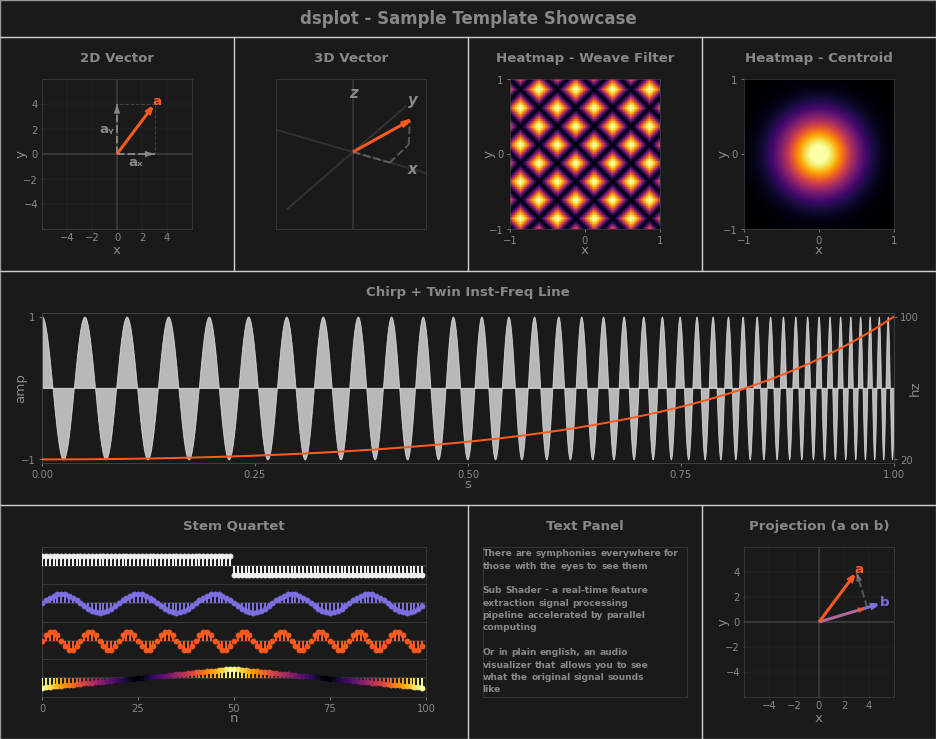

In [6]:
# dsplot - Sample Template (kitchen-sink showcase)
from dsplot.figures import sample_template
sample_template.show()


In [7]:
import sys
_purged = [m for m in list(sys.modules) if m == "dsplot" or m.startswith("dsplot.")]
for _m in _purged:
    del sys.modules[_m]
from dsplot.figures import figure_1, figure_2_4_1, figure_2_4_2
import dsplot
print("purged", len(_purged), "dsplot modules")
print("has DynamicTextPanel:", hasattr(dsplot, "DynamicTextPanel"))
print("has RichText:", hasattr(dsplot, "RichText"))
print("content border inset:", dsplot.style.DEFAULT_CONTENT_BORDER_INSET_FRAC)
print("figure_2_4_2 module:", figure_2_4_2.__module__)


purged 38 dsplot modules
has DynamicTextPanel: True
has RichText: True
content border inset: 0.0625
figure_2_4_2 module: dsplot.figures.gen_figure_242_a_onto_b


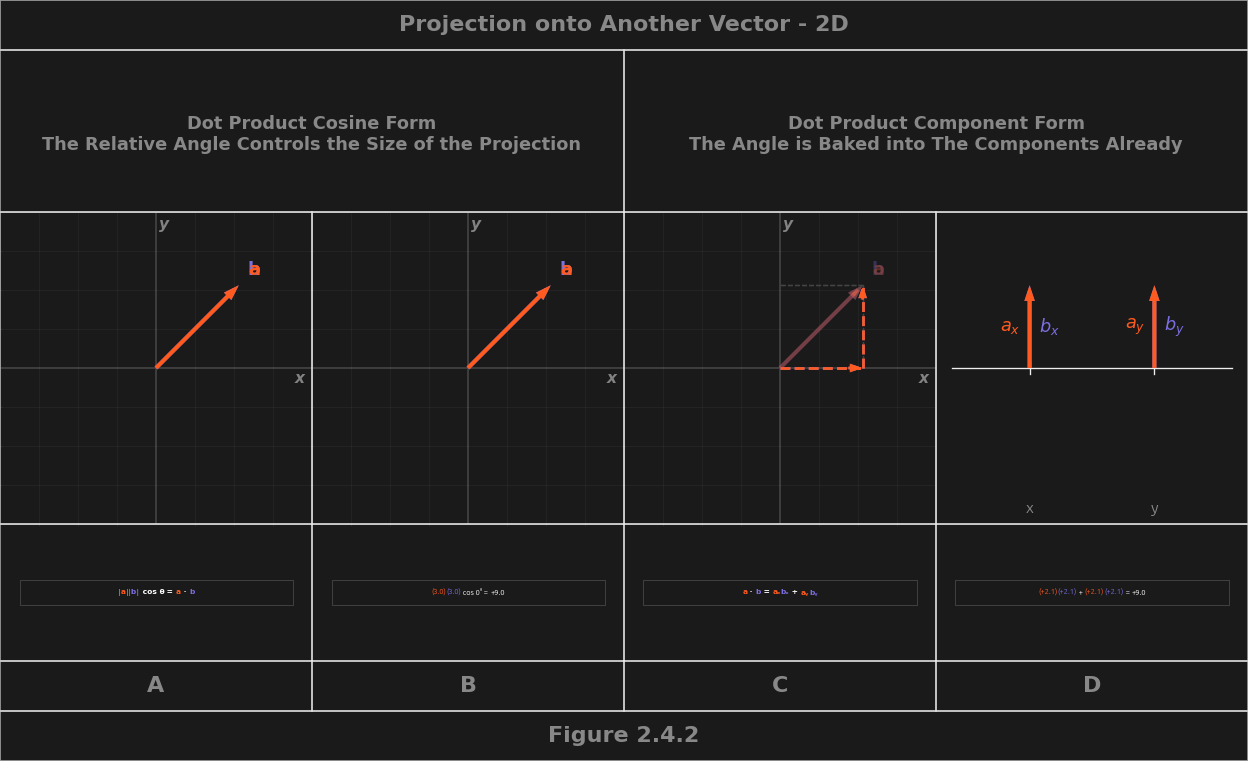

In [8]:
figure_2_4_2()

purged 38 dsplot modules; reloaded figure_2_4_2


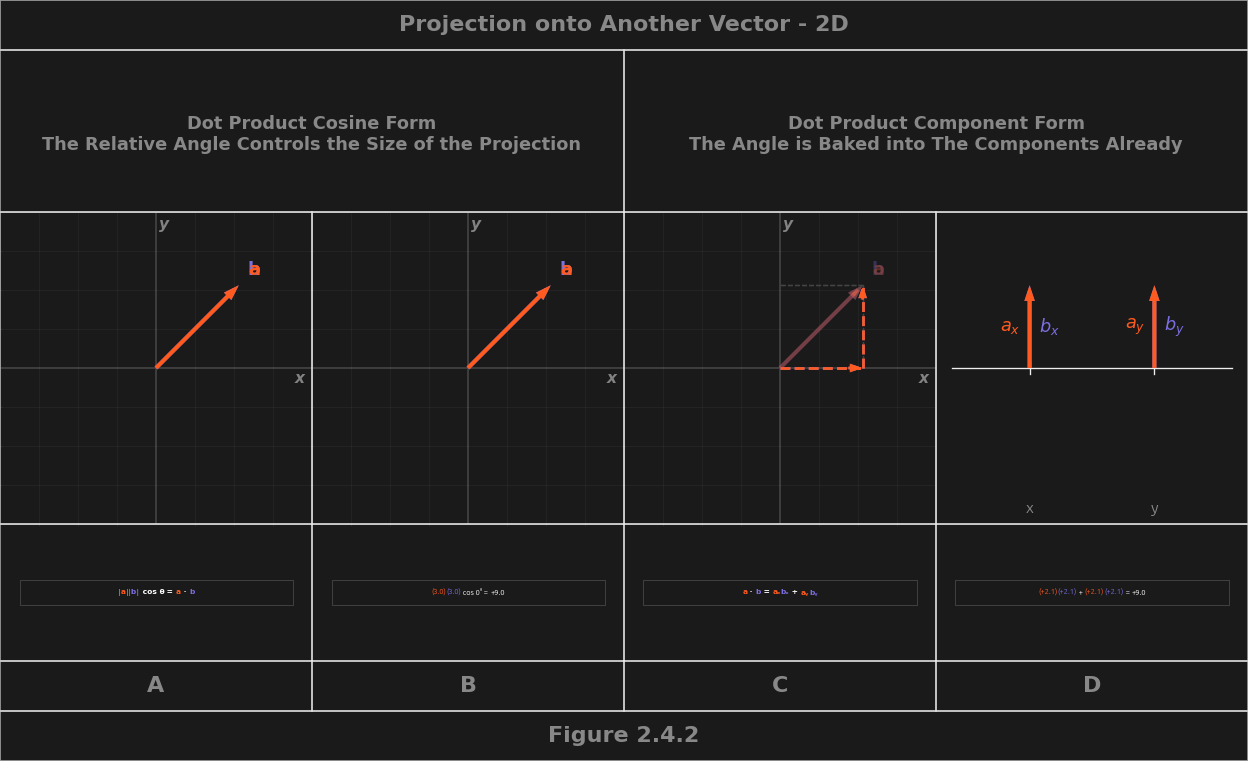

In [9]:
import sys
_purged = [m for m in list(sys.modules) if m == "dsplot" or m.startswith("dsplot.")]
for _m in _purged:
    del sys.modules[_m]
from dsplot.figures import figure_2_4_2
print(f"purged {len(_purged)} dsplot modules; reloaded figure_2_4_2")
figure_2_4_2()

purged 38 dsplot modules; module -> dsplot.figures.gen_figure_242_a_onto_b


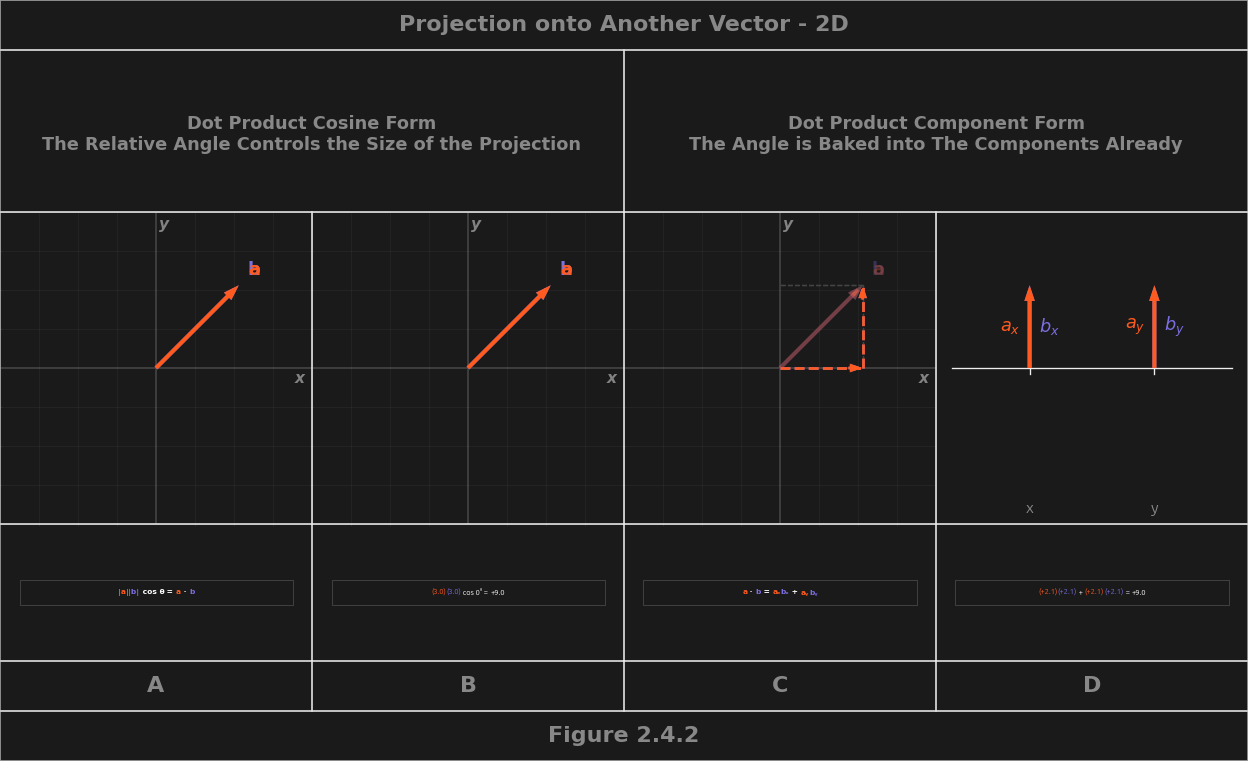

In [10]:
import sys
_purged = [m for m in list(sys.modules) if m == "dsplot" or m.startswith("dsplot.")]
for _m in _purged:
    del sys.modules[_m]
from dsplot.figures import figure_2_4_2
print(f"purged {len(_purged)} dsplot modules; module ->", figure_2_4_2.__module__)
figure_2_4_2()